# CT slice with Ground Truth

CT shape: (512, 512, 212)
GT mask shape: (1, 512, 512, 212)
GT labels: [0. 1. 2.]
Using GT mask shape: (512, 512, 212)
Displaying slice: 110

Voxel counts
CT total voxels        : 55574528
Mask total voxels      : 55574528
Mask positive voxels   : 2781
Mask background voxels : 55571747
Mask percentage of CT  : 0.005004%


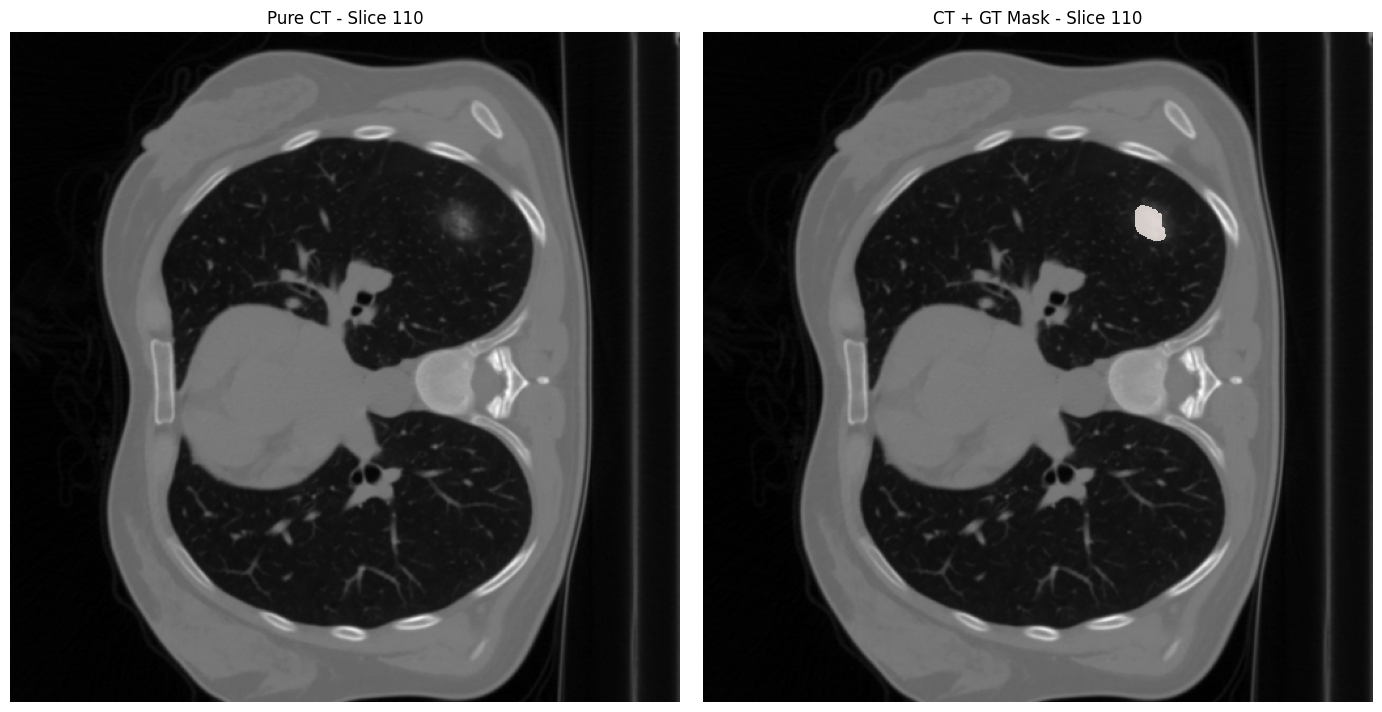

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Load NIfTI files
# -----------------------------

volume_path = r"C:\Users\chamu\D\UOR\FYP\fyp\data\data_volumes\dataset\train_fixed\train_12165\train_12165_a\train_12165_a_1.nii.gz"

mask_path = r"C:\Users\chamu\D\UOR\FYP\fyp\data\segmentations\segmentations\train_12165_a_1.nii.gz"


ct = nib.load(volume_path).get_fdata()
gt_mask = nib.load(mask_path).get_fdata()


print("CT shape:", ct.shape)
print("GT mask shape:", gt_mask.shape)
print("GT labels:", np.unique(gt_mask)[:20])


# -----------------------------
# Handle mask dimensions
# -----------------------------

if gt_mask.ndim == 4:
    finding = 0
    gt_mask = gt_mask[finding]

print("Using GT mask shape:", gt_mask.shape)


# -----------------------------
# Find slice with most nodule
# -----------------------------

slice_idx = np.argmax(
    (gt_mask > 0).sum(axis=(0, 1))
)

print("Displaying slice:", slice_idx)

# -----------------------------
# Voxel counts
# -----------------------------

ct_voxels = ct.size
mask_voxels = gt_mask.size

positive_mask_voxels = np.count_nonzero(gt_mask > 0)
zero_mask_voxels = mask_voxels - positive_mask_voxels

mask_percentage_of_volume = (positive_mask_voxels / ct_voxels) * 100

print("\nVoxel counts")
print("CT total voxels        :", ct_voxels)
print("Mask total voxels      :", mask_voxels)
print("Mask positive voxels   :", positive_mask_voxels)
print("Mask background voxels :", zero_mask_voxels)
print(f"Mask percentage of CT  : {mask_percentage_of_volume:.6f}%")


# -----------------------------
# Plot volume + overlay
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 7))


# Pure CT volume
axes[0].imshow(
    ct[:, :, slice_idx],
    cmap="gray"
)

axes[0].set_title(f"Pure CT - Slice {slice_idx}")
axes[0].axis("off")


# CT + GT mask overlay
axes[1].imshow(
    ct[:, :, slice_idx],
    cmap="gray"
)

seg = gt_mask[:, :, slice_idx]

axes[1].imshow(
    np.ma.masked_where(
        seg <= 0,
        seg
    ),
    cmap="Reds",
    alpha=0.8,
    interpolation="none"
)

axes[1].set_title(f"CT + GT Mask - Slice {slice_idx}")
axes[1].axis("off")


plt.tight_layout()
plt.show()

# How much is covered by 12³ and 16³

CT shape: (512, 512, 407)
GT shape: (1, 512, 512, 407)
Final GT shape: (512, 512, 407)
Visualization slice: 288

Selected lesion center:
X=94, Y=276, Z=287

---------------------------
12x12x12 cube
---------------------------
Cube shape: (12, 12, 12)
Lesion voxels: 244
Total voxels: 1728
Lesion fraction: 0.1412
Lesion percentage: 14.12%
Accepted: False

---------------------------
16x16x16 cube
---------------------------
Cube shape: (16, 16, 16)
Lesion voxels: 247
Total voxels: 4096
Lesion fraction: 0.0603
Lesion percentage: 6.03%
Accepted: False


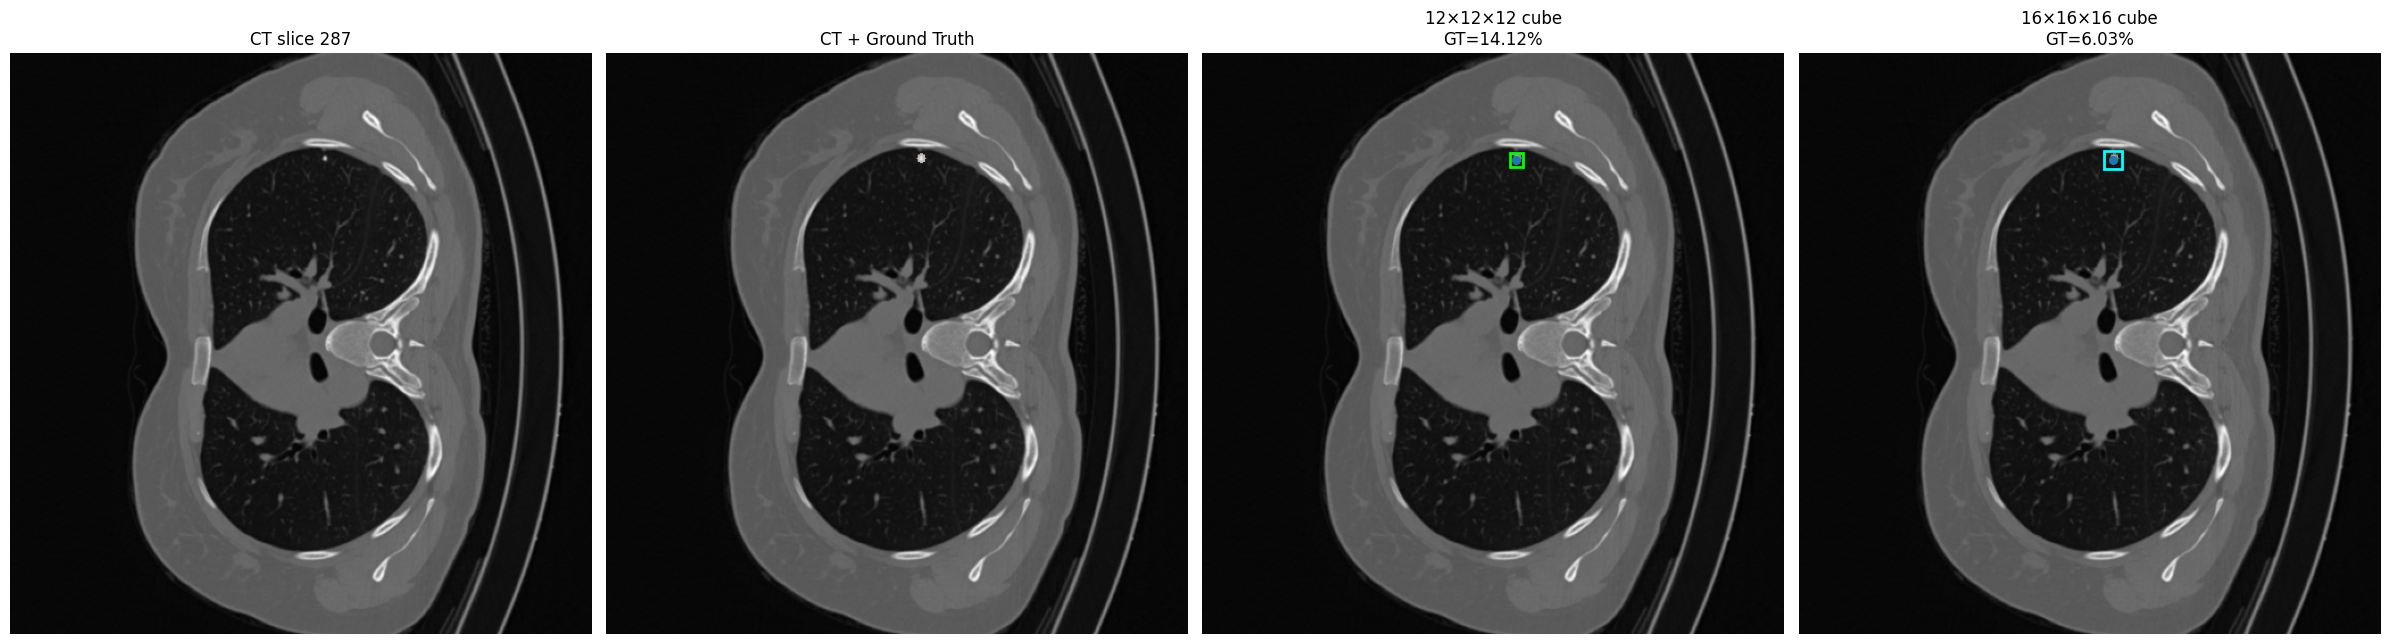

In [7]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Paths
# ============================================================

volume_path = r"/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_396_a_1.nii.gz"
mask_path = r"/home/chest_ct/code/data/segmentations/segmentations/train_396_a_1.nii.gz"

# ============================================================
# Load CT and GT mask
# ============================================================

ct = nib.load(volume_path).get_fdata()
gt_mask = nib.load(mask_path).get_fdata()

print("CT shape:", ct.shape)
print("GT shape:", gt_mask.shape)

# If segmentation has finding dimension
if gt_mask.ndim == 4:
    gt_mask = gt_mask[0]

print("Final GT shape:", gt_mask.shape)

# ============================================================
# Find slice with largest lesion
# ============================================================

slice_idx = np.argmax(
    (gt_mask > 0).sum(axis=(0,1))
)

print("Visualization slice:", slice_idx)

# ============================================================
# Find lesion center
# IMPORTANT: np.argwhere returns (X,Y,Z)
# ============================================================

coords = np.argwhere(gt_mask > 0)


if len(coords) == 0:
    raise ValueError("No lesion found")

center_x, center_y, center_z = coords[len(coords)//2]

print(
    "\nSelected lesion center:"
)
print(
    f"X={center_x}, Y={center_y}, Z={center_z}"
)

# Use lesion center slice
slice_idx = center_z



# ============================================================
# Extract 3D cube
# ============================================================

def extract_cube(mask, center, size):
    x, y, z = center
    half = size // 2

    x1 = x - half
    x2 = x + half

    y1 = y - half
    y2 = y + half

    z1 = z - half
    z2 = z + half


    cube = mask[
        x1:x2,
        y1:y2,
        z1:z2
    ]


    return cube



# ============================================================
# Calculate lesion fraction
# ============================================================

LESION_FRACTION_THRESHOLD = 0.5


cube_results = {}


for size in [12,16]:

    cube = extract_cube(
        gt_mask,
        (center_x, center_y, center_z),
        size
    )


    fraction = (
        cube > 0
    ).mean()


    cube_results[size] = fraction


    print("\n---------------------------")
    print(f"{size}x{size}x{size} cube")
    print("---------------------------")

    print(
        "Cube shape:",
        cube.shape
    )
    print(
        "Lesion voxels:",
        np.count_nonzero(cube > 0)
    )
    print(
        "Total voxels:",
        cube.size
    )
    print(
        f"Lesion fraction: {fraction:.4f}"
    )
    print(
        f"Lesion percentage: {fraction*100:.2f}%"
    )
    print(
        "Accepted:",
        fraction >= LESION_FRACTION_THRESHOLD
    )



# ============================================================
# Plot helper
# ============================================================

def show_cube(ax, size, color):

    half = size // 2


    # imshow coordinate:
    # x-axis -> Y
    # y-axis -> X

    top_left_x = center_y - half
    top_left_y = center_x - half


    rect = plt.Rectangle(
        (top_left_x, top_left_y),
        size,
        size,
        fill=False,
        linewidth=2,
        edgecolor=color
    )


    ax.add_patch(rect)



# ============================================================
# Visualization
# ============================================================

fig, axes = plt.subplots(
    1,
    4,
    figsize=(24,7)
)

# -----------------------------
# CT only
# -----------------------------

axes[0].imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)
axes[0].set_title(
    f"CT slice {slice_idx}"
)
axes[0].axis("off")



# -----------------------------
# GT mask
# -----------------------------

axes[1].imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)
axes[1].imshow(
    np.ma.masked_where(
        gt_mask[:,:,slice_idx] <= 0,
        gt_mask[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.7
)
axes[1].set_title(
    "CT + Ground Truth"
)
axes[1].axis("off")



# -----------------------------
# 12x12x12 cube
# -----------------------------

axes[2].imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)
axes[2].imshow(
    np.ma.masked_where(
        gt_mask[:,:,slice_idx] <= 0,
        gt_mask[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.5
)
show_cube(
    axes[2],
    12,
    "lime"
)
axes[2].scatter(
    center_y,
    center_x,
    s=30
)
axes[2].set_title(
    f"12×12×12 cube\n"
    f"GT={cube_results[12]*100:.2f}%"
)
axes[2].axis("off")



# -----------------------------
# 16x16x16 cube
# -----------------------------

axes[3].imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)
axes[3].imshow(
    np.ma.masked_where(
        gt_mask[:,:,slice_idx] <= 0,
        gt_mask[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.5
)
show_cube(
    axes[3],
    16,
    "cyan"
)
axes[3].scatter(
    center_y,
    center_x,
    s=30
)
axes[3].set_title(
    f"16×16×16 cube\n"
    f"GT={cube_results[16]*100:.2f}%"
)
axes[3].axis("off")



plt.tight_layout()
plt.show()

# Patch Extraction

CT: (512, 512, 512)
Mask: (6, 512, 512, 512)
Binary mask: (512, 512, 512)
Foreground voxels: 52340

Bounding box
(np.int64(160), np.int64(353), np.int64(188), np.int64(235), np.int64(372), np.int64(405))

Collected patches: 3725

Patch index: 497
Origin: (211, 213, 367)
Lesion fraction: 0.611083984375
Patch L2 norm: 53759.77698986483


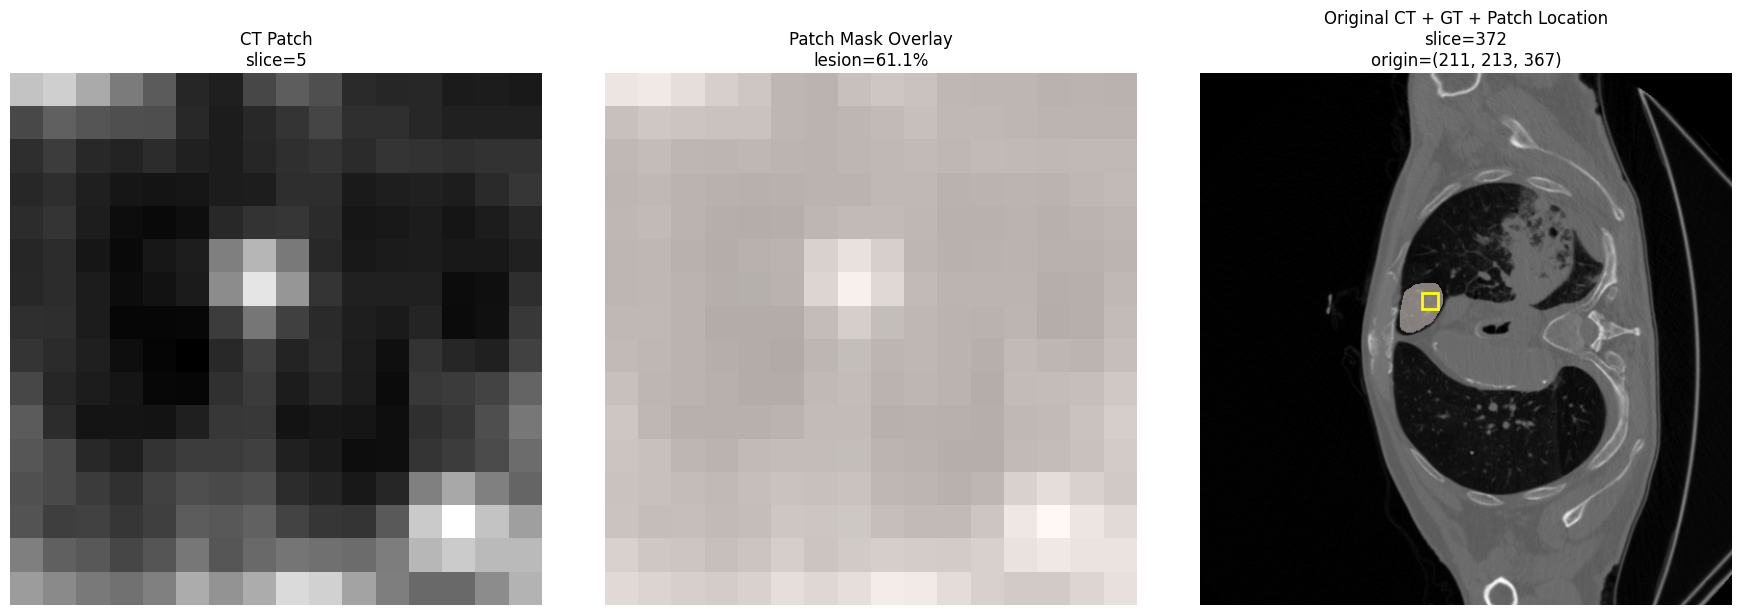


Patch index: 3146
Origin: (321, 207, 383)
Lesion fraction: 0.6064453125
Patch L2 norm: 56373.63427170542


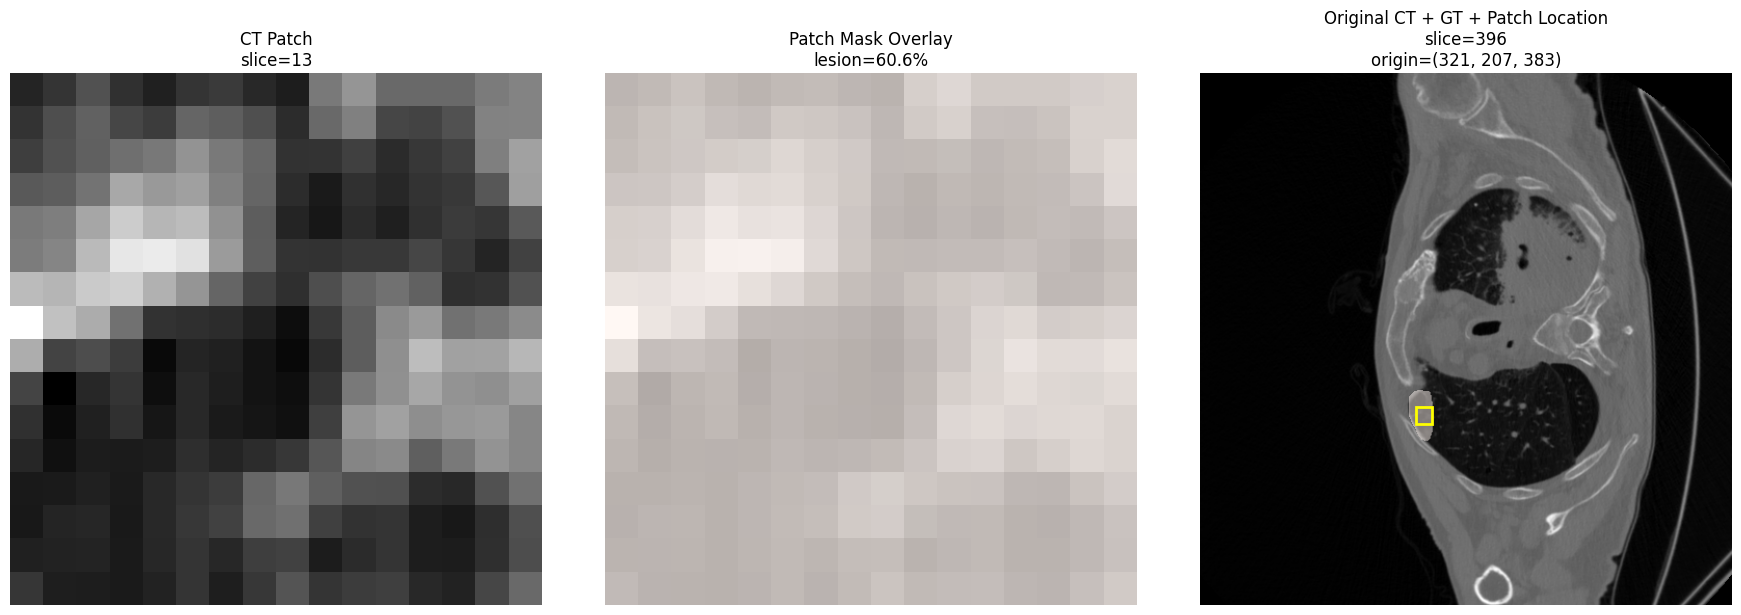


Patch index: 1148
Origin: (227, 195, 375)
Lesion fraction: 0.7236328125
Patch L2 norm: 45450.24384973088


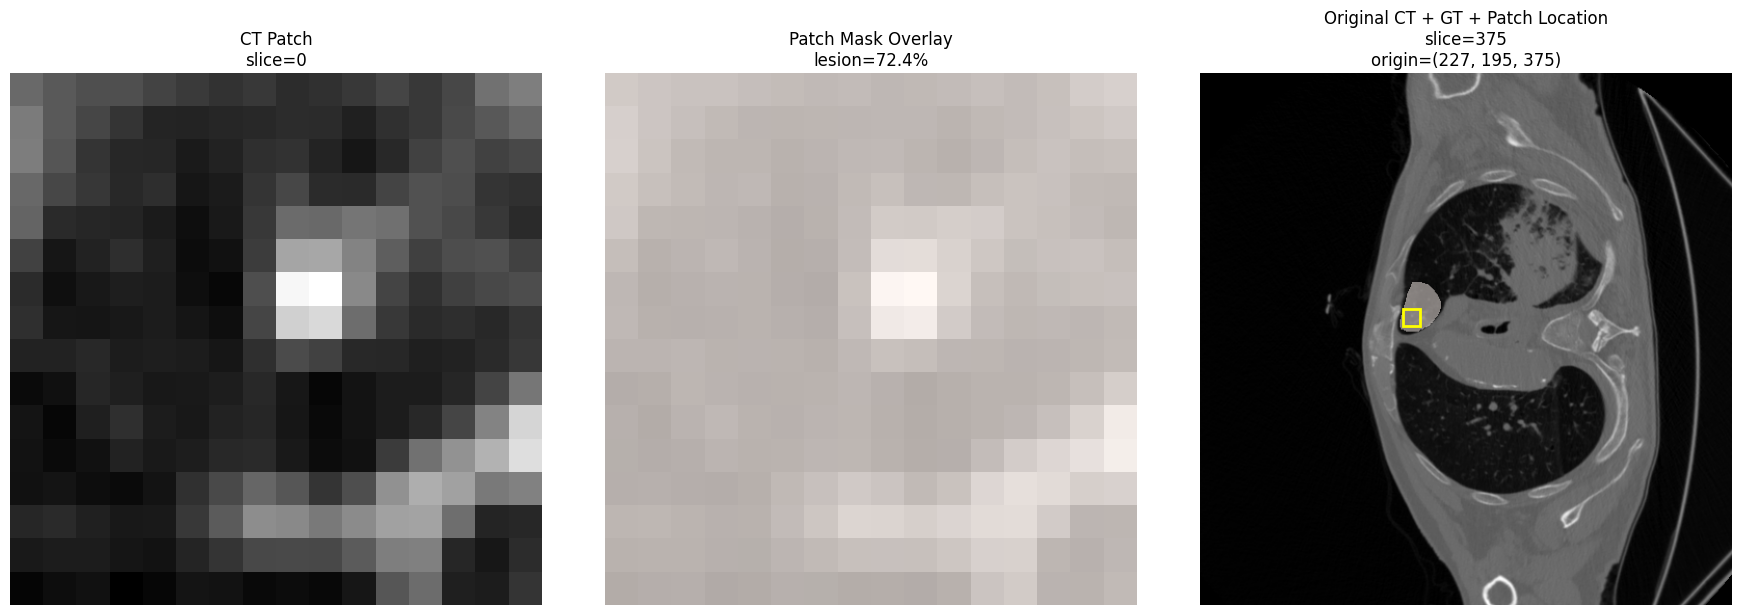


Patch index: 2822
Origin: (315, 217, 393)
Lesion fraction: 0.52783203125
Patch L2 norm: 51858.63774724516


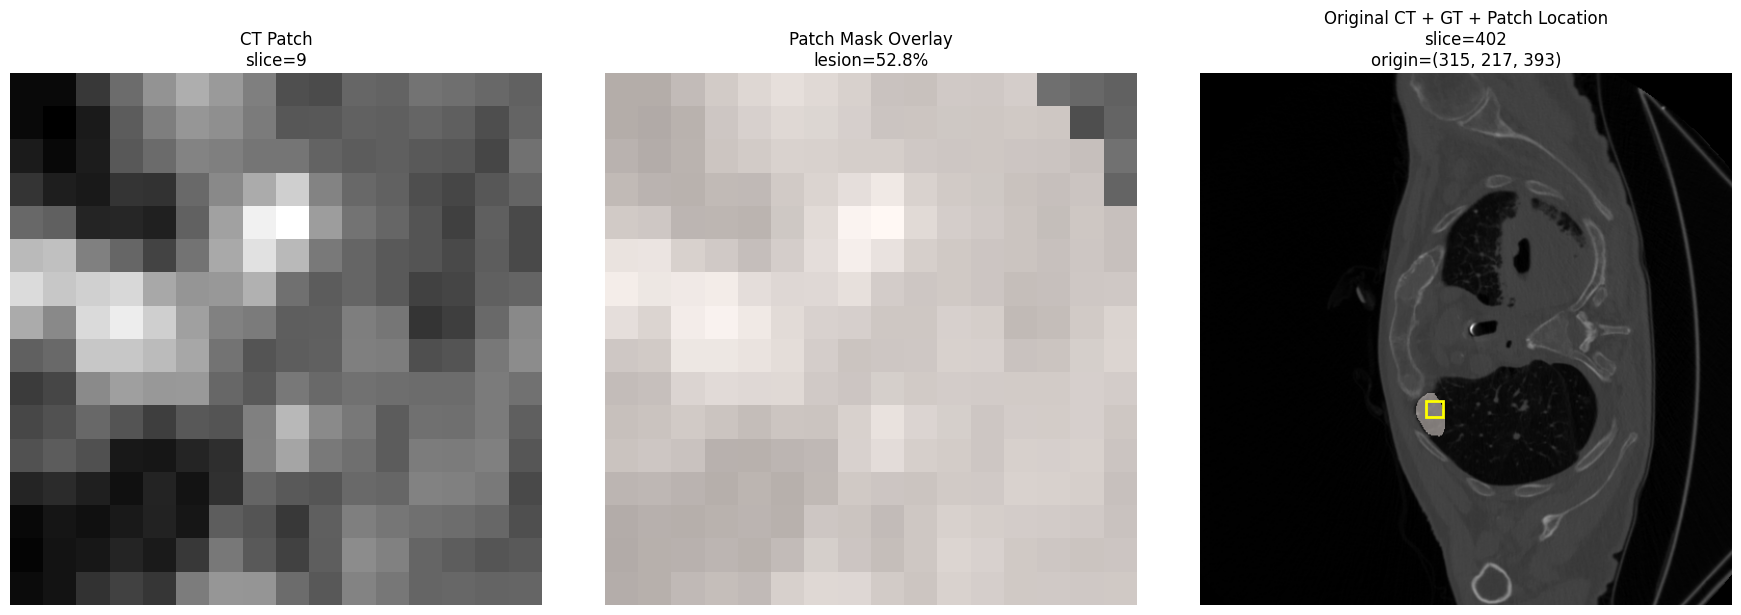


Patch index: 2267
Origin: (305, 205, 383)
Lesion fraction: 0.689697265625
Patch L2 norm: 55238.685963733784


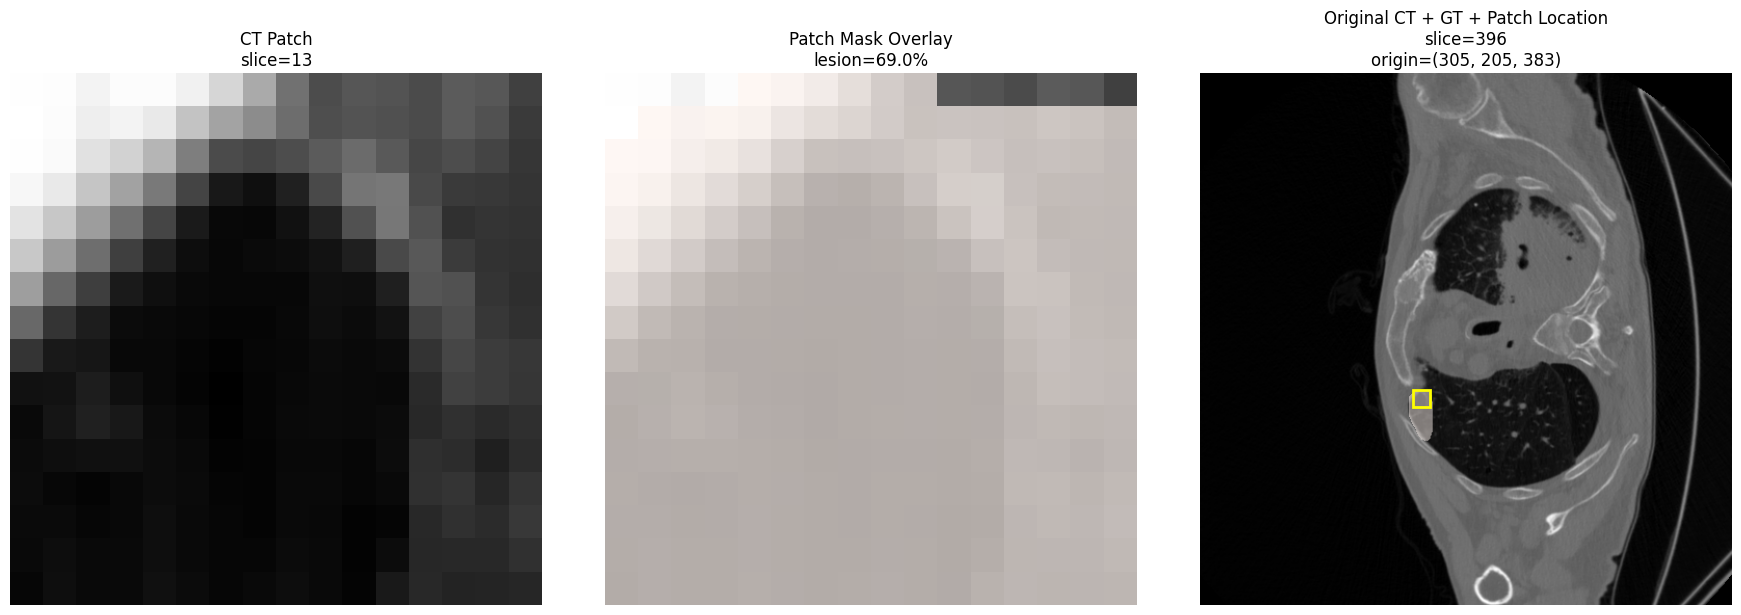

In [3]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


# =============================
# Parameters (same as pipeline)
# =============================

PATCH_SIZE = 16
ABNORMAL_PATCH_STRIDE = 2
LESION_FRACTION_THRESHOLD = 0.5


# =============================
# Load CT and mask
# =============================

volume_path = r"/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_1448_c_2.nii.gz"
mask_path = r"/home/chest_ct/code/data/segmentations/segmentations/train_1448_c_2.nii.gz"


ct = nib.load(volume_path).get_fdata()
mask = nib.load(mask_path).get_fdata()


print("CT:", ct.shape)
print("Mask:", mask.shape)


# Handle 4D masks
if mask.ndim == 4:
    finding = 0
    mask = mask[finding]


mask = (mask > 0).astype(np.uint8)

print("Binary mask:", mask.shape)
print("Foreground voxels:", mask.sum())



# =============================
# Helper functions (same logic)
# =============================

def has_sufficient_lesion(mask_patch):
    return (mask_patch > 0).mean() >= LESION_FRACTION_THRESHOLD



def foreground_bbox(binary_mask):

    coords = np.argwhere(binary_mask > 0)

    x_min, y_min, z_min = coords.min(axis=0)
    x_max, y_max, z_max = coords.max(axis=0)

    return (
        x_min, x_max,
        y_min, y_max,
        z_min, z_max
    )



def bbox_origins(bbox, volume_shape, stride):

    p = PATCH_SIZE

    H, W, D = volume_shape

    x_min, x_max, y_min, y_max, z_min, z_max = bbox


    x_start = max(0, x_min - p + 1)
    x_stop  = min(H-p, x_max)

    y_start = max(0, y_min - p + 1)
    y_stop  = min(W-p, y_max)

    z_start = max(0, z_min - p + 1)
    z_stop  = min(D-p, z_max)


    for x0 in range(x_start, x_stop+1, stride):
        for y0 in range(y_start, y_stop+1, stride):
            for z0 in range(z_start, z_stop+1, stride):
                yield x0,y0,z0



def extract_patch(volume, x,y,z):

    return volume[
        x:x+PATCH_SIZE,
        y:y+PATCH_SIZE,
        z:z+PATCH_SIZE
    ]



# =============================
# Generate patches
# =============================

bbox = foreground_bbox(mask)

print("\nBounding box")
print(bbox)


patches = []


for x,y,z in bbox_origins(
    bbox,
    ct.shape,
    ABNORMAL_PATCH_STRIDE
):

    ct_patch = extract_patch(ct,x,y,z)
    mask_patch = extract_patch(mask,x,y,z)


    if has_sufficient_lesion(mask_patch):

        patches.append(
            {
                "origin":(x,y,z),
                "ct":ct_patch,
                "mask":mask_patch,
                "lesion_fraction":(mask_patch>0).mean()
            }
        )


print("\nCollected patches:",len(patches))



# =============================
# Visualize selected patches
# =============================

def show_patch(patch):

    ct_patch = patch["ct"]
    mask_patch = patch["mask"]

    x0, y0, z0 = patch["origin"]


    # choose patch slice with highest lesion pixels
    slice_idx = np.argmax(
        (mask_patch > 0).sum(axis=(0,1))
    )

    # Corresponding slice in original CT
    original_z = z0 + slice_idx


    fig, ax = plt.subplots(
        1, 3,
        figsize=(18, 6)
    )


    # ---------------------------------
    # 1. Patch CT
    # ---------------------------------

    ax[0].imshow(
        ct_patch[:, :, slice_idx],
        cmap="gray"
    )

    ax[0].set_title(
        f"CT Patch\nslice={slice_idx}"
    )

    ax[0].axis("off")



    # ---------------------------------
    # 2. Patch + mask overlay
    # ---------------------------------

    ax[1].imshow(
        ct_patch[:, :, slice_idx],
        cmap="gray"
    )

    ax[1].imshow(
        np.ma.masked_where(
            mask_patch[:, :, slice_idx] == 0,
            mask_patch[:, :, slice_idx]
        ),
        cmap="Reds",
        alpha=0.7
    )

    ax[1].set_title(
        f"Patch Mask Overlay\n"
        f"lesion={patch['lesion_fraction']*100:.1f}%"
    )

    ax[1].axis("off")



    # ---------------------------------
    # 3. Original CT + GT + patch box
    # ---------------------------------

    ax[2].imshow(
        ct[:, :, original_z],
        cmap="gray"
    )


    # Full GT mask overlay
    ax[2].imshow(
        np.ma.masked_where(
            mask[:, :, original_z] == 0,
            mask[:, :, original_z]
        ),
        cmap="Reds",
        alpha=0.5
    )


    # Draw patch bounding box
    rect = plt.Rectangle(
        (y0, x0),
        PATCH_SIZE,
        PATCH_SIZE,
        fill=False,
        edgecolor="yellow",
        linewidth=2
    )

    ax[2].add_patch(rect)


    ax[2].set_title(
        f"Original CT + GT + Patch Location\n"
        f"slice={original_z}\n"
        f"origin={patch['origin']}"
    )

    ax[2].axis("off")


    plt.tight_layout()
    plt.show()



import numpy as np

# Number of random patches to display
num_show = 5

# Select random patch indices
random_indices = np.random.choice(
    len(patches),
    size=min(num_show, len(patches)),
    replace=False
)


for i in random_indices:

    p = patches[i]

    patch_norm = np.linalg.norm(p["ct"])


    print(
        f"\nPatch index: {i}"
    )

    print(
        "Origin:",
        p["origin"]
    )

    print(
        "Lesion fraction:",
        p["lesion_fraction"]
    )

    print(
        "Patch L2 norm:",
        patch_norm
    )

    show_patch(p)

## Ground Truth Voxels

Number of GT voxels: 946

HU distribution inside GT mask
Min : -870.0
P1  : -806.55
P5  : -732.5
P25 : -349.75
P50 : -160.5
P75 : -23.0
P95 : 72.0
P99 : 87.09999999999991
Max : 185.0
Mean: -214.89429175475686
Median: -160.5
Std : 242.02840726892504


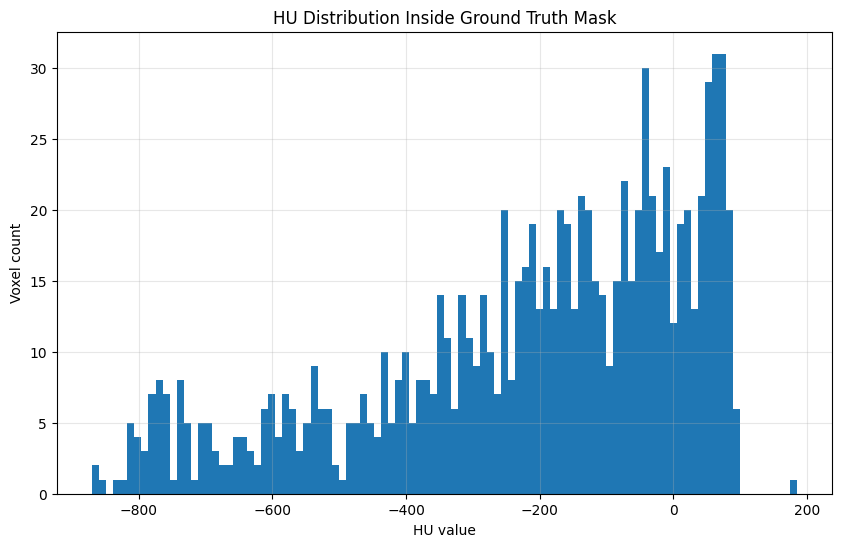

In [11]:
# ============================================================
# HU distribution inside GT mask
# ============================================================


# If GT mask is multi-channel, select one finding/channel
if gt_mask.ndim == 4:
    finding = 0
    gt_mask_single = gt_mask[finding]
else:
    gt_mask_single = gt_mask

# Convert GT to boolean mask
gt_bool = gt_mask_single > 0

# Extract HU values inside GT
gt_hu_values = ct[gt_bool]

# Remove NaN / inf if any
gt_hu_values = gt_hu_values[np.isfinite(gt_hu_values)]

print("Number of GT voxels:", gt_hu_values.size)

if gt_hu_values.size > 0:
    print("\nHU distribution inside GT mask")
    print("Min :", float(np.min(gt_hu_values)))
    print("P1  :", float(np.percentile(gt_hu_values, 1)))
    print("P5  :", float(np.percentile(gt_hu_values, 5)))
    print("P25 :", float(np.percentile(gt_hu_values, 25)))
    print("P50 :", float(np.percentile(gt_hu_values, 50)))  # median
    print("P75 :", float(np.percentile(gt_hu_values, 75)))
    print("P95 :", float(np.percentile(gt_hu_values, 95)))
    print("P99 :", float(np.percentile(gt_hu_values, 99)))
    print("Max :", float(np.max(gt_hu_values)))
    print("Mean:", float(np.mean(gt_hu_values)))
    print("Median:", float(np.median(gt_hu_values)))
    print("Std :", float(np.std(gt_hu_values)))

    # Plot histogram
    plt.figure(figsize=(10, 6))
    plt.hist(gt_hu_values, bins=100)
    plt.xlabel("HU value")
    plt.ylabel("Voxel count")
    plt.title("HU Distribution Inside Ground Truth Mask")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("GT mask is empty.")


Selected CTs: 524

Processed: 524
Missing CTs: 0
Missing masks: 0

========== GLOBAL NODULE HU STATS ==========
Voxel count: 2191527
P1 : -982.0
P5 : -859.0
P25: -402.0
P50: 6.0
P75: 40.0
P95: 81.0
P99: 118.0
Min   : -1091.0
Max   : 3071.0
Mean  : -179.4037709779528
Std   : 338.8326628855829


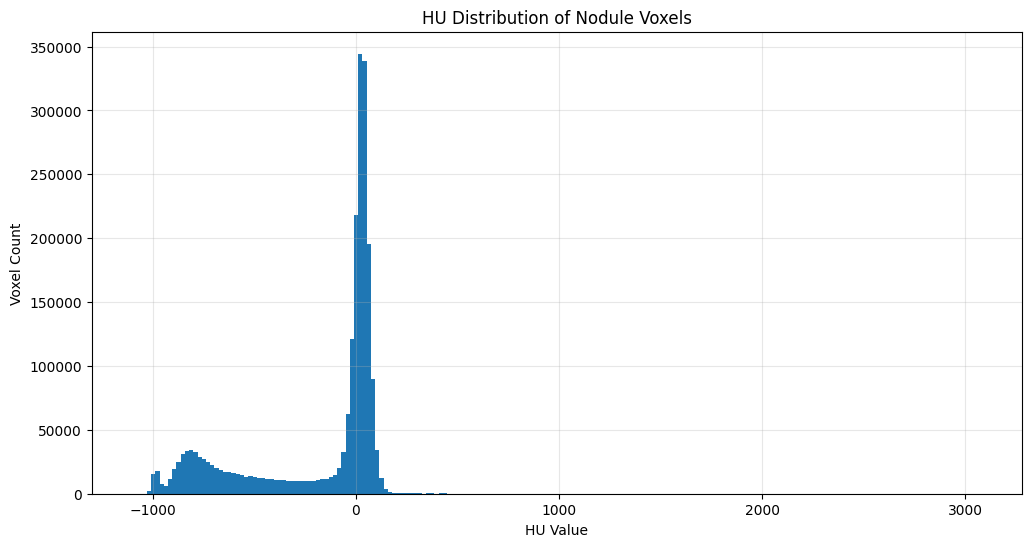

In [31]:
import os
import json
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths
# --------------------------------------------------

volume_dir = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed"
mask_dir = "/home/chest_ct/code/data/segmentations/segmentations"

json_path = "/home/chest_ct/code/data/rexgrounding-ct/dataset_2d.json"

# --------------------------------------------------
# Load selected cases
# --------------------------------------------------

with open(json_path, "r") as f:
    dataset = json.load(f)

selected_files = set(
    dataset.get("train", []) +
    dataset.get("test", [])
)

print(f"Selected CTs: {len(selected_files)}")

# --------------------------------------------------
# Collect HU values
# --------------------------------------------------

all_hu_values = []

processed = 0
missing_ct = []
missing_mask = []

for filename in sorted(selected_files):

    volume_path = os.path.join(volume_dir, filename)
    mask_path = os.path.join(mask_dir, filename)

    if not os.path.exists(volume_path):
        missing_ct.append(filename)
        continue

    if not os.path.exists(mask_path):
        missing_mask.append(filename)
        continue

    try:
        ct = nib.load(volume_path).get_fdata()
        gt_mask = nib.load(mask_path).get_fdata()

        # Multi-channel mask -> union of channels
        if gt_mask.ndim == 4:
            gt_mask = np.any(gt_mask > 0, axis=0)
        else:
            gt_mask = gt_mask > 0

        hu_values = ct[gt_mask]
        hu_values = hu_values[np.isfinite(hu_values)]

        if hu_values.size > 0:
            all_hu_values.append(hu_values)

        processed += 1

    except Exception as e:
        print(f"Error processing {filename}: {e}")

# --------------------------------------------------
# Summary
# --------------------------------------------------

print(f"\nProcessed: {processed}")
print(f"Missing CTs: {len(missing_ct)}")
print(f"Missing masks: {len(missing_mask)}")

if missing_ct:
    print("\nMissing CT files:")
    for x in missing_ct[:20]:
        print(" ", x)

if missing_mask:
    print("\nMissing mask files:")
    for x in missing_mask[:20]:
        print(" ", x)

# --------------------------------------------------
# HU statistics
# --------------------------------------------------

all_hu_values = np.concatenate(all_hu_values)

print("\n========== GLOBAL NODULE HU STATS ==========")
print("Voxel count:", all_hu_values.size)

for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"P{p:<2}:", float(np.percentile(all_hu_values, p)))

print("Min   :", float(np.min(all_hu_values)))
print("Max   :", float(np.max(all_hu_values)))
print("Mean  :", float(np.mean(all_hu_values)))
print("Std   :", float(np.std(all_hu_values)))

# --------------------------------------------------
# Histogram
# --------------------------------------------------

plt.figure(figsize=(12, 6))
plt.hist(all_hu_values, bins=200)
plt.xlabel("HU Value")
plt.ylabel("Voxel Count")
plt.title("HU Distribution of Nodule Voxels")
plt.grid(alpha=0.3)
plt.show()

In [32]:
# ============================================================
# Narrowest HU ranges containing given percentages of GT values
# ============================================================

def narrowest_hu_range(values, percentages=[1, 5, 10, 15, 50]):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    values = np.sort(values)

    n = values.size

    if n == 0:
        print("No HU values found.")
        return {}

    results = {}

    for p in percentages:
        # Number of voxels needed to include p%
        window_size = max(1, int(np.ceil((p / 100) * n)))

        # Sliding window over sorted HU values
        starts = values[: n - window_size + 1]
        ends = values[window_size - 1 :]

        widths = ends - starts
        best_idx = int(np.argmin(widths))

        hu_min = float(starts[best_idx])
        hu_max = float(ends[best_idx])
        width = float(hu_max - hu_min)

        results[p] = {
            "min": hu_min,
            "max": hu_max,
            "width": width,
            "voxels": window_size,
        }

        print(f"{p}% HU range:")
        print(f"  Min HU : {hu_min:.2f}")
        print(f"  Max HU : {hu_max:.2f}")
        print(f"  Width  : {width:.2f}")
        print(f"  Voxels : {window_size}")
        print()

    return results


hu_ranges = narrowest_hu_range(gt_hu_values, percentages=[1, 5, 10, 25, 50])

1% HU range:
  Min HU : 59.00
  Max HU : 60.00
  Width  : 1.00
  Voxels : 10

5% HU range:
  Min HU : 59.00
  Max HU : 73.00
  Width  : 14.00
  Voxels : 48

10% HU range:
  Min HU : 44.00
  Max HU : 76.00
  Width  : 32.00
  Voxels : 95

25% HU range:
  Min HU : -41.00
  Max HU : 73.00
  Width  : 114.00
  Voxels : 237

50% HU range:
  Min HU : -173.00
  Max HU : 80.00
  Width  : 253.00
  Voxels : 473



In [33]:
hu_ranges_all = narrowest_hu_range(
    all_hu_values,
    percentages=[1, 5, 10, 25, 50]
)

1% HU range:
  Min HU : -1.00
  Max HU : 0.00
  Width  : 1.00
  Voxels : 21916

5% HU range:
  Min HU : 16.00
  Max HU : 22.00
  Width  : 6.00
  Voxels : 109577

10% HU range:
  Min HU : 18.00
  Max HU : 30.00
  Width  : 12.00
  Voxels : 219153

25% HU range:
  Min HU : 10.00
  Max HU : 42.00
  Width  : 32.00
  Voxels : 547882

50% HU range:
  Min HU : -15.00
  Max HU : 67.00
  Width  : 82.00
  Voxels : 1095764



In [ ]:
import numpy as np
from pathlib import Path

npz_path = Path("/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_shuffled.npz")
data = np.load(npz_path, allow_pickle=True)

print("Arrays stored in the NPZ:\n")
for key in data.files:
    arr = data[key]
    print(f"{key:15s} shape={arr.shape} dtype={arr.dtype}")

Arrays stored in the NPZ:

X               shape=(1728, 118705) dtype=float64
H               shape=(118705,) dtype=int64
scan_ids        shape=(118705,) dtype=object
coords          shape=(118705, 3) dtype=int64


In [ ]:
import numpy as np
from pathlib import Path
from collections import Counter

npz_path = Path("/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_shuffled.npz")
data = np.load(npz_path, allow_pickle=True)

H = data["H"]

print("Unique labels:", np.unique(H))
print()

print("Patch count per label:")
for label, count in sorted(Counter(H.tolist()).items()):
    print(f"Label {label}: {count} patches")

Unique labels: [0 1 2]

Patch count per label:
Label 0: 67766 patches
Label 1: 27196 patches
Label 2: 23743 patches


# Visualizing patch sizes

In [ ]:
import nibabel as nib
from pathlib import Path

# Define paths
data_volumes_path = Path("/home/chest_ct/code/data/data_volumes/dataset")
patch_size = 32

# Helper function to count 32x32x32 patches
def count_32x32x32_patches(ct_volume):
    """Count how many non-overlapping 32x32x32 patches fit in a CT volume"""
    shape = ct_volume.shape
    patches_per_axis = [s // patch_size for s in shape]
    total_patches = patches_per_axis[0] * patches_per_axis[1] * patches_per_axis[2]
    return total_patches, patches_per_axis

# Find CT volumes and count patches
total_patches = 0
volume_patch_info = []
found_count = 0
not_found_count = 0

print("Searching for CT volumes from 100 normal lungs...")
print("=" * 80)

for i, item in enumerate(normal_lungs_100):
    scan_name = item['name']
    
    # Search for the file in data_volumes folder
    matches = list(data_volumes_path.rglob(scan_name))
    
    if matches:
        try:
            ct_img = nib.load(matches[0])
            ct_data = ct_img.get_fdata()
            shape = ct_data.shape
            
            patches, patches_per_axis = count_32x32x32_patches(ct_data)
            total_patches += patches
            found_count += 1
            
            volume_patch_info.append({
                'name': scan_name,
                'shape': shape,
                'patches_32x32x32': patches,
                'patches_per_axis': patches_per_axis,
                'path': str(matches[0])
            })
            
            if (i + 1) % 10 == 0:
                print(f"Processed {i + 1} volumes... Found: {found_count}, Total patches so far: {total_patches}")
        except Exception as e:
            print(f"Error loading {scan_name}: {e}")
            not_found_count += 1
    else:
        not_found_count += 1
        if not_found_count <= 5:  # Show first 5 not found
            print(f"Not found: {scan_name}")

print("\n" + "=" * 80)
print(f"SUMMARY:")
print(f"Total volumes found and processed: {found_count}")
print(f"Total volumes NOT found: {not_found_count}")
print(f"\nTOTAL 32×32×32 PATCHES from 100 normal lung volumes: {total_patches}")
print("=" * 80)

# Show distribution of patches
patch_counts_df = pd.DataFrame(volume_patch_info)[['name', 'shape', 'patches_32x32x32']]
print(f"\nTop 10 volumes by patch count:")
print(patch_counts_df.nlargest(10, 'patches_32x32x32'))
print(f"\nAverage patches per volume: {total_patches / found_count:.1f}")
print(f"Min patches: {patch_counts_df['patches_32x32x32'].min()}")
print(f"Max patches: {patch_counts_df['patches_32x32x32'].max()}")

Searching for CT volumes from 100 normal lungs...


NameError: name 'normal_lungs_100' is not defined

In [35]:
import json
import numpy as np
import pandas as pd
import nibabel as nib
from collections import defaultdict
from pathlib import Path

# Count 32x32x32 patches per disease category using RexGrounding-CT abnormal masks.
# A patch is counted if it contains at least one non-zero voxel from the disease mask.
patch_size = 32
patch_counts_by_category = defaultdict(int)
scan_counts_by_category = defaultdict(int)
example_rows = []

rex_data_path = Path("/home/chest_ct/code/data/rexgrounding-ct/dataset_3.json")
ct_volume_root = Path("/home/chest_ct/code/data/data_volumes/dataset")
seg_root = Path("/home/chest_ct/code/data/segmentations/segmentations")

with open(rex_data_path, "r") as f:
    rex_data = json.load(f)

all_categories = sorted({
    cat
    for split in ["train", "val", "test"]
    for item in rex_data.get(split, [])
    for cat in item.get("categories", {}).values()
})


def pad_to_multiple_3d(arr, m=32):
    pad_width = [(0, (m - s % m) % m) for s in arr.shape]
    return np.pad(arr, pad_width, mode="constant", constant_values=0)


def count_occupied_patches_3d(mask3d, m=32):
    mask3d = (mask3d > 0).astype(np.uint8)
    mask3d = pad_to_multiple_3d(mask3d, m)

    sx, sy, sz = mask3d.shape
    patches = mask3d.reshape(
        sx // m, m,
        sy // m, m,
        sz // m, m,
    )
    patches = patches.transpose(0, 2, 4, 1, 3, 5)
    patches = patches.reshape(-1, m, m, m)
    return int(np.sum(np.any(patches, axis=(1, 2, 3))))


for split in ["train", "val", "test"]:
    for item in rex_data.get(split, []):
        scan_name = item.get("name")
        categories = item.get("categories", {})

        if not scan_name or not categories:
            continue

        ct_matches = list(ct_volume_root.rglob(scan_name))
        seg_matches = list(seg_root.rglob(scan_name))

        if not ct_matches or not seg_matches:
            continue

        try:
            ct_img = nib.load(ct_matches[0])
            seg_img = nib.load(seg_matches[0])
        except Exception as e:
            print(f"Skipping {scan_name} due to load error: {e}")
            continue

        seg_data = seg_img.get_fdata()
        if seg_data.ndim != 4:
            continue

        for finding_idx in range(seg_data.shape[0]):
            category = categories.get(str(finding_idx))
            if category is None:
                continue

            mask3d = seg_data[finding_idx]
            if not np.any(mask3d):
                continue

            patch_count = count_occupied_patches_3d(mask3d, patch_size)
            patch_counts_by_category[category] += patch_count
            scan_counts_by_category[category] += 1

            example_rows.append({
                "scan_name": scan_name,
                "category": category,
                "finding_idx": finding_idx,
                "ct_shape": tuple(ct_img.shape),
                "seg_shape": tuple(seg_data.shape),
                "patch_count": patch_count,
            })

patch_counts_df = (
    pd.DataFrame(example_rows)
    .sort_values(["category", "scan_name", "finding_idx"])
    .reset_index(drop=True)
)

summary_df = (
    pd.DataFrame({
        "category": list(patch_counts_by_category.keys()),
        "scan_count": [scan_counts_by_category[c] for c in patch_counts_by_category.keys()],
        "total_32x32x32_patches": [patch_counts_by_category[c] for c in patch_counts_by_category.keys()],
    })
    .sort_values("total_32x32x32_patches", ascending=False)
    .reset_index(drop=True)
)

print("Disease-level 32x32x32 patch count summary")
print("=" * 80)
print(summary_df)
print("\nTop 10 scan/category rows:")
print(patch_counts_df.head(10))
print("\nCategories seen:")
print(all_categories)


KeyboardInterrupt: 

Raw CT shape: (512, 512, 412)
Raw segmentation shape: (1, 512, 512, 412)

Selected case
Split: train
Scan: train_2239_a_2.nii.gz
Category: 2c
Finding index: 0
Finding: Widespread and patchy ground-glass opacities in both lungs, more prominently in the right lung
CT path: /home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_2239_a_2.nii.gz
Segmentation path: /home/chest_ct/code/data/segmentations/segmentations/train_2239_a_2.nii.gz
CT shape: (512, 512, 412)
Mask shape: (512, 512, 412)
Total abnormal voxels in finding: 395209
Patch grid index: (np.int64(4), np.int64(9), np.int64(9))
Patch start [x, y, z]: [128, 288, 288]
Patch end [x, y, z]: [160, 320, 320]
Patch shape: (32, 32, 32)
Abnormal voxels in patch: 27728
Displayed global z slice: 294
Abnormal voxels in displayed slice: 1024


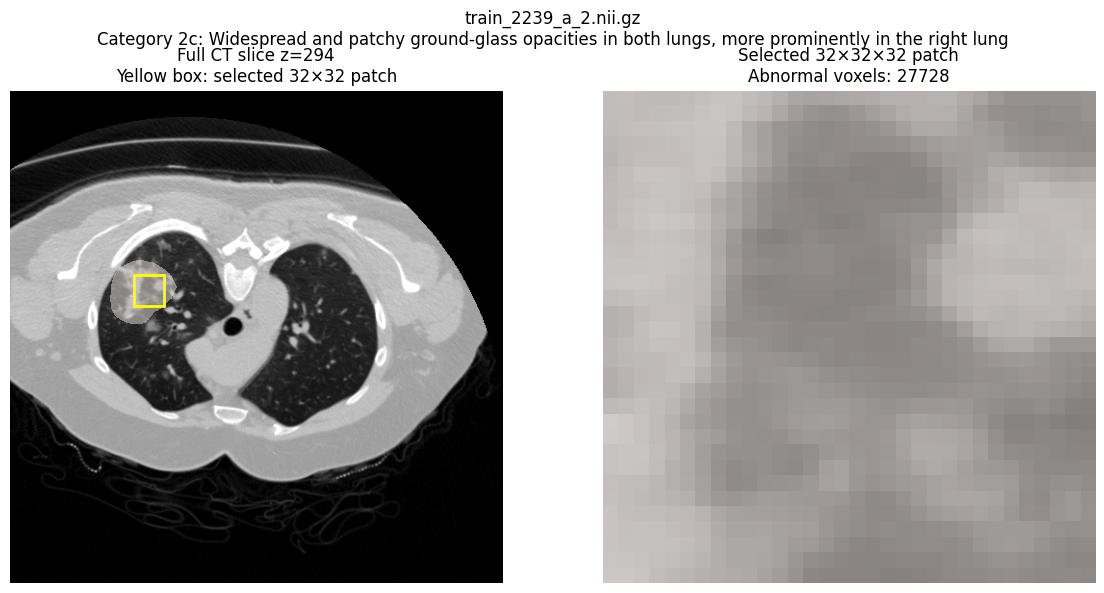

In [ ]:
import json
from pathlib import Path

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


# ============================================================
# Settings
# ============================================================

dataset_path = Path(
    "/home/chest_ct/code/data/rexgrounding-ct/dataset_3.json"
)

ct_root = Path(
    "/home/chest_ct/code/data/data_volumes/dataset"
)

seg_root = Path(
    "/home/chest_ct/code/data/segmentations/segmentations"
)

scan_name = "train_2239_a_2.nii.gz"
target_category = "2c"
patch_size = 32


# ============================================================
# Find metadata for the selected scan
# ============================================================

with open(dataset_path, "r") as f:
    dataset = json.load(f)

sample = None
finding_idx = None

for split in ["train", "val", "test"]:
    for item in dataset.get(split, []):
        if item.get("name") != scan_name:
            continue

        for key, category in item.get("categories", {}).items():
            if str(category).strip().lower() == target_category:
                sample = item
                finding_idx = int(key)
                selected_split = split
                break

        if sample is not None:
            break

    if sample is not None:
        break

if sample is None:
    raise ValueError(
        f"No {target_category} finding found for {scan_name}"
    )


# ============================================================
# Find and load CT and segmentation
# ============================================================

ct_matches = list(ct_root.rglob(scan_name))
seg_matches = list(seg_root.rglob(scan_name))

if not ct_matches:
    raise FileNotFoundError(f"CT not found: {scan_name}")

if not seg_matches:
    raise FileNotFoundError(f"Segmentation not found: {scan_name}")

ct_path = ct_matches[0]
seg_path = seg_matches[0]

ct = nib.load(ct_path).get_fdata(dtype=np.float32)
seg = np.asanyarray(nib.load(seg_path).dataobj)

print("Raw CT shape:", ct.shape)
print("Raw segmentation shape:", seg.shape)


# ============================================================
# Extract the selected finding mask
# ============================================================

# Expected ReXGrounding-CT format:
# F × H × W × D
if seg.ndim != 4:
    raise ValueError(
        f"Expected F×H×W×D segmentation, received {seg.shape}"
    )

if finding_idx >= seg.shape[0]:
    raise IndexError(
        f"Finding index {finding_idx} is invalid for shape {seg.shape}"
    )

mask = seg[finding_idx] > 0

if not mask.any():
    raise ValueError(
        f"Finding channel {finding_idx} contains no abnormal voxels."
    )

if ct.shape != mask.shape:
    raise ValueError(
        f"CT and mask shapes differ:\n"
        f"CT: {ct.shape}\n"
        f"Mask: {mask.shape}\n"
        "The spatial axis order must be checked before extracting patches."
    )


# ============================================================
# Pad to multiples of 32
# ============================================================

padding = [
    (0, (patch_size - size % patch_size) % patch_size)
    for size in ct.shape
]

ct_padded = np.pad(
    ct,
    padding,
    mode="constant",
    constant_values=-1000,
)

mask_padded = np.pad(
    mask.astype(np.uint8),
    padding,
    mode="constant",
    constant_values=0,
)


# ============================================================
# Divide mask into non-overlapping 32×32×32 patches
# ============================================================

nx = mask_padded.shape[0] // patch_size
ny = mask_padded.shape[1] // patch_size
nz = mask_padded.shape[2] // patch_size

patch_voxel_counts = mask_padded.reshape(
    nx, patch_size,
    ny, patch_size,
    nz, patch_size,
).transpose(
    0, 2, 4, 1, 3, 5
).sum(axis=(3, 4, 5))


# Select the patch containing the most abnormal voxels
patch_grid_index = np.unravel_index(
    np.argmax(patch_voxel_counts),
    patch_voxel_counts.shape,
)

gx, gy, gz = patch_grid_index

start = np.array([
    gx * patch_size,
    gy * patch_size,
    gz * patch_size,
])

end = start + patch_size


# ============================================================
# Extract CT and mask patches
# ============================================================

ct_patch = ct_padded[
    start[0]:end[0],
    start[1]:end[1],
    start[2]:end[2],
]

mask_patch = mask_padded[
    start[0]:end[0],
    start[1]:end[1],
    start[2]:end[2],
]

if ct_patch.shape != (32, 32, 32):
    raise ValueError(f"Unexpected CT patch shape: {ct_patch.shape}")

if mask_patch.shape != (32, 32, 32):
    raise ValueError(f"Unexpected mask patch shape: {mask_patch.shape}")


# Select the axial patch slice with the largest abnormal area
abnormal_per_slice = mask_patch.sum(axis=(0, 1))
local_z = int(np.argmax(abnormal_per_slice))

global_z = int(start[2] + local_z)


# ============================================================
# Information
# ============================================================

finding_text = sample.get("findings", {}).get(
    str(finding_idx),
    "Unknown finding",
)

print("\nSelected case")
print("=" * 70)
print("Split:", selected_split)
print("Scan:", scan_name)
print("Category:", target_category)
print("Finding index:", finding_idx)
print("Finding:", finding_text)
print("CT path:", ct_path)
print("Segmentation path:", seg_path)
print("CT shape:", ct.shape)
print("Mask shape:", mask.shape)
print("Total abnormal voxels in finding:", int(mask.sum()))
print("Patch grid index:", patch_grid_index)
print("Patch start [x, y, z]:", start.tolist())
print("Patch end [x, y, z]:", end.tolist())
print("Patch shape:", ct_patch.shape)
print("Abnormal voxels in patch:", int(mask_patch.sum()))
print("Displayed global z slice:", global_z)
print(
    "Abnormal voxels in displayed slice:",
    int(mask_patch[:, :, local_z].sum())
)


# ============================================================
# Visualize
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 6))


# Full CT slice
axes[0].imshow(
    ct_padded[:, :, global_z].T,
    cmap="gray",
    origin="lower",
    vmin=-1000,
    vmax=400,
)

full_overlay = np.ma.masked_where(
    mask_padded[:, :, global_z].T == 0,
    mask_padded[:, :, global_z].T,
)

axes[0].imshow(
    full_overlay,
    cmap="Reds",
    origin="lower",
    alpha=0.45,
    interpolation="nearest",
)

axes[0].add_patch(
    Rectangle(
        (start[0], start[1]),
        patch_size,
        patch_size,
        edgecolor="yellow",
        facecolor="none",
        linewidth=2,
    )
)

axes[0].set_title(
    f"Full CT slice z={global_z}\n"
    "Yellow box: selected 32×32 patch"
)

axes[0].axis("off")


# Extracted patch
axes[1].imshow(
    ct_patch[:, :, local_z].T,
    cmap="gray",
    origin="lower",
    vmin=-1000,
    vmax=400,
)

patch_overlay = np.ma.masked_where(
    mask_patch[:, :, local_z].T == 0,
    mask_patch[:, :, local_z].T,
)

axes[1].imshow(
    patch_overlay,
    cmap="Reds",
    origin="lower",
    alpha=0.45,
    interpolation="nearest",
)

axes[1].set_title(
    f"Selected 32×32×32 patch\n"
    f"Abnormal voxels: {int(mask_patch.sum())}"
)

axes[1].axis("off")

plt.suptitle(
    f"{scan_name}\nCategory 2c: {finding_text}",
    fontsize=12,
)

plt.tight_layout()
plt.show()

Selected 5 category 2d cases.

Case 1
Split: train
Scan: train_1741_c_2.nii.gz
Finding index: 1
Finding: Subcentimeter nonspecific nodules in both lungs
Total finding-mask voxels: 462
Patch grid index: (np.int64(9), np.int64(22), np.int64(10))
Patch start [x, y, z]: [144, 352, 160]
Patch end [x, y, z]: [160, 368, 176]
Nodule voxels in patch: 275
Displayed CT z slice: 166

Case 2
Split: train
Scan: train_1591_c_2.nii.gz
Finding index: 5
Finding: Subcentimeter nonspecific parenchymal nodules in both lungs
Total finding-mask voxels: 4746
Patch grid index: (np.int64(16), np.int64(22), np.int64(16))
Patch start [x, y, z]: [256, 352, 256]
Patch end [x, y, z]: [272, 368, 272]
Nodule voxels in patch: 2541
Displayed CT z slice: 265

Case 3
Split: train
Scan: train_1959_b_2.nii.gz
Finding index: 6
Finding: Well-defined cavitary nodules measuring 8 mm in the superior segment of the left lower lobe
Total finding-mask voxels: 2903
Patch grid index: (np.int64(22), np.int64(22), np.int64(16))
Patch s

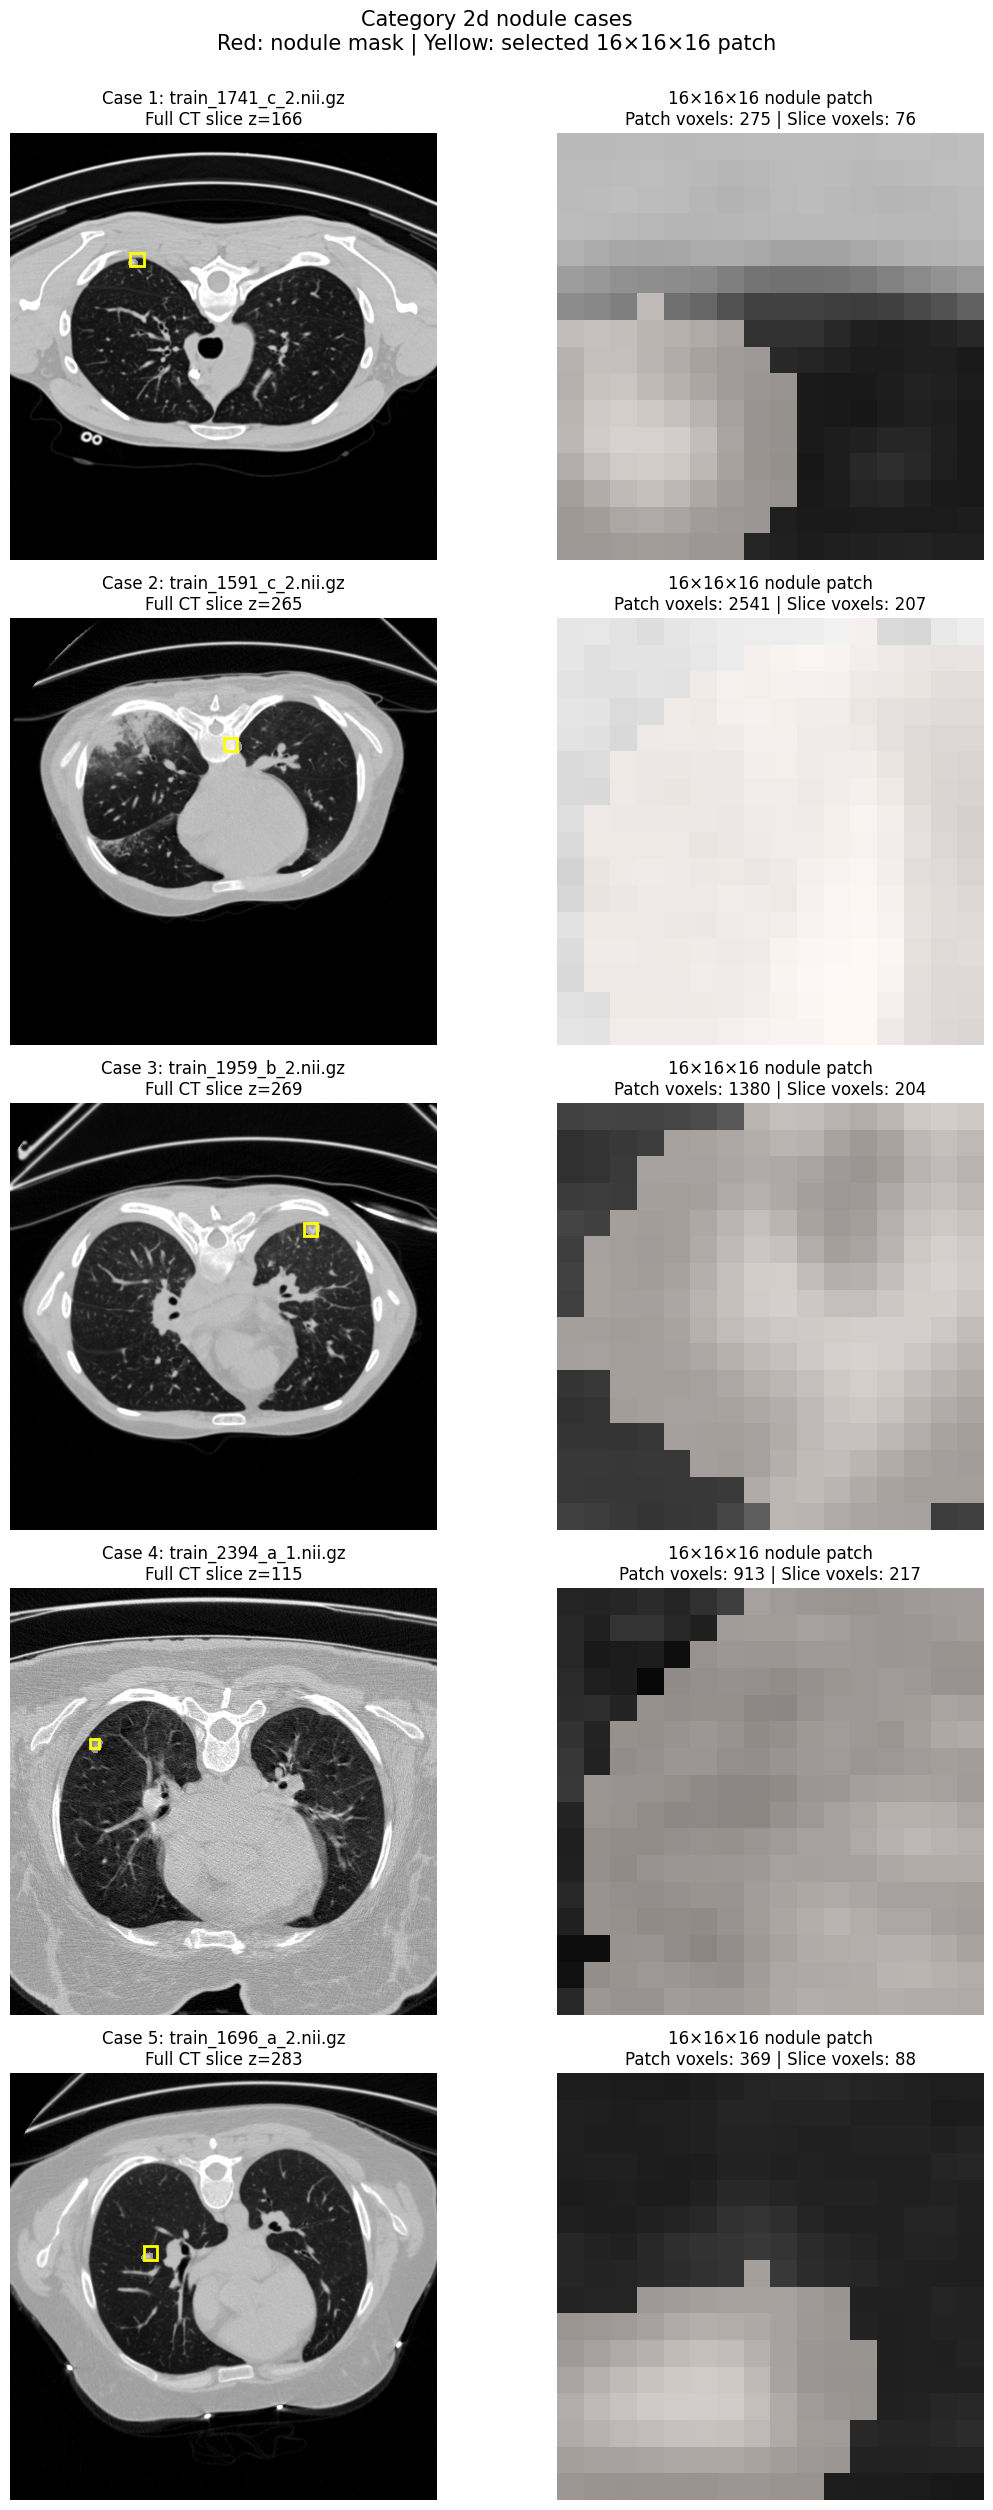

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import nibabel as nib
import numpy as n1


# ============================================================
# Settings
# ============================================================

dataset_path = Path(
    "/home/chest_ct/code/data/rexgrounding-ct/dataset_3.json"
)

ct_root = Path(
    "/home/chest_ct/code/data/data_volumes/dataset"
)

seg_root = Path(
    "/home/chest_ct/code/data/segmentations/segmentations"
)

target_category = "2d"
patch_size = 16

# Number of nodule cases to visualize
num_cases = 5

# CT display window
window_min = -1000
window_max = 400


# ============================================================
# Load metadata
# ============================================================

with open(dataset_path, "r") as f:
    dataset = json.load(f)


# ============================================================
# Helper: select the most lesion-rich fixed-grid patch
# ============================================================

def extract_best_patch(ct, mask, patch_size=32):
    """
    Divide the CT and mask into non-overlapping fixed-grid patches
    and return the patch containing the largest number of mask voxels.
    """

    padding = [
        (0, (patch_size - size % patch_size) % patch_size)
        for size in mask.shape
    ]

    ct_padded = np.pad(
        ct,
        padding,
        mode="constant",
        constant_values=-1000,
    )

    mask_padded = np.pad(
        mask.astype(np.uint8),
        padding,
        mode="constant",
        constant_values=0,
    )

    nx = mask_padded.shape[0] // patch_size
    ny = mask_padded.shape[1] // patch_size
    nz = mask_padded.shape[2] // patch_size

    patch_counts = mask_padded.reshape(
        nx, patch_size,
        ny, patch_size,
        nz, patch_size,
    ).transpose(
        0, 2, 4, 1, 3, 5
    ).sum(axis=(3, 4, 5))

    patch_grid_index = np.unravel_index(
        np.argmax(patch_counts),
        patch_counts.shape,
    )

    gx, gy, gz = patch_grid_index

    start = np.array([
        gx * patch_size,
        gy * patch_size,
        gz * patch_size,
    ])

    end = start + patch_size

    ct_patch = ct_padded[
        start[0]:end[0],
        start[1]:end[1],
        start[2]:end[2],
    ]

    mask_patch = mask_padded[
        start[0]:end[0],
        start[1]:end[1],
        start[2]:end[2],
    ]

    # Select the axial patch slice containing the most nodule voxels
    local_z = int(
        np.argmax(mask_patch.sum(axis=(0, 1)))
    )

    global_z = int(start[2] + local_z)

    return {
        "ct_padded": ct_padded,
        "mask_padded": mask_padded,
        "ct_patch": ct_patch,
        "mask_patch": mask_patch,
        "patch_grid_index": patch_grid_index,
        "start": start,
        "end": end,
        "local_z": local_z,
        "global_z": global_z,
        "patch_voxel_count": int(mask_patch.sum()),
    }


# ============================================================
# Find several valid 2d nodule cases
# ============================================================

selected_cases = []

for split in ["train", "val", "test"]:
    for item in dataset.get(split, []):

        if len(selected_cases) >= num_cases:
            break

        scan_name = item.get("name")

        if not scan_name:
            continue

        for key, category in item.get("categories", {}).items():

            if str(category).strip().lower() != target_category:
                continue

            finding_idx = int(key)

            ct_matches = list(ct_root.rglob(scan_name))
            seg_matches = list(seg_root.rglob(scan_name))

            if not ct_matches or not seg_matches:
                continue

            try:
                ct = nib.load(
                    ct_matches[0]
                ).get_fdata(dtype=np.float32)

                seg = np.asanyarray(
                    nib.load(seg_matches[0]).dataobj
                )

                if seg.ndim != 4:
                    continue

                if finding_idx >= seg.shape[0]:
                    continue

                mask = seg[finding_idx] > 0

                if not mask.any():
                    continue

                if ct.shape != mask.shape:
                    print(
                        f"Skipping {scan_name}: "
                        f"CT shape {ct.shape} != mask shape {mask.shape}"
                    )
                    continue

                patch_data = extract_best_patch(
                    ct,
                    mask,
                    patch_size=patch_size,
                )

                # Ensure that the selected patch actually contains a nodule
                if patch_data["patch_voxel_count"] == 0:
                    continue

                finding_text = item.get(
                    "findings", {}
                ).get(
                    str(finding_idx),
                    "Unknown nodule finding",
                )

                selected_cases.append({
                    "split": split,
                    "scan_name": scan_name,
                    "finding_idx": finding_idx,
                    "finding_text": finding_text,
                    "ct_path": ct_matches[0],
                    "seg_path": seg_matches[0],
                    "total_mask_voxels": int(mask.sum()),
                    **patch_data,
                })

                break

            except Exception as error:
                print(
                    f"Skipping {scan_name}, "
                    f"finding {finding_idx}: {error}"
                )

    if len(selected_cases) >= num_cases:
        break


if not selected_cases:
    raise ValueError(
        "No valid category 2d nodule cases were found."
    )

print(f"Selected {len(selected_cases)} category 2d cases.")


# ============================================================
# Print selected case information
# ============================================================

for case_number, case in enumerate(selected_cases, start=1):

    print("\n" + "=" * 80)
    print(f"Case {case_number}")
    print("=" * 80)

    print("Split:", case["split"])
    print("Scan:", case["scan_name"])
    print("Finding index:", case["finding_idx"])
    print("Finding:", case["finding_text"])
    print("Total finding-mask voxels:", case["total_mask_voxels"])
    print("Patch grid index:", case["patch_grid_index"])
    print("Patch start [x, y, z]:", case["start"].tolist())
    print("Patch end [x, y, z]:", case["end"].tolist())
    print("Nodule voxels in patch:", case["patch_voxel_count"])
    print("Displayed CT z slice:", case["global_z"])


# ============================================================
# Visualize all selected cases
# ============================================================

number_of_rows = len(selected_cases)

fig, axes = plt.subplots(
    number_of_rows,
    2,
    figsize=(12, 5 * number_of_rows),
)

# Keep axes two-dimensional when only one case is selected
if number_of_rows == 1:
    axes = np.array([axes])


for row, case in enumerate(selected_cases):

    full_ax = axes[row, 0]
    patch_ax = axes[row, 1]

    global_z = case["global_z"]
    local_z = case["local_z"]
    start = case["start"]

    ct_padded = case["ct_padded"]
    mask_padded = case["mask_padded"]

    ct_patch = case["ct_patch"]
    mask_patch = case["mask_patch"]


    # --------------------------------------------------------
    # Full CT slice
    # --------------------------------------------------------

    full_ax.imshow(
        ct_padded[:, :, global_z].T,
        cmap="gray",
        origin="lower",
        vmin=window_min,
        vmax=window_max,
    )

    full_mask_slice = mask_padded[:, :, global_z].T

    full_overlay = np.ma.masked_where(
        full_mask_slice == 0,
        full_mask_slice,
    )

    full_ax.imshow(
        full_overlay,
        cmap="Reds",
        origin="lower",
        alpha=0.55,
        interpolation="nearest",
    )

    full_ax.add_patch(
        Rectangle(
            (start[0], start[1]),
            patch_size,
            patch_size,
            edgecolor="yellow",
            facecolor="none",
            linewidth=2,
        )
    )

    full_ax.set_title(
        f"Case {row + 1}: {case['scan_name']}\n"
        f"Full CT slice z={global_z}"
    )

    full_ax.axis("off")


    # --------------------------------------------------------
    # Extracted nodule patch
    # --------------------------------------------------------

    patch_ax.imshow(
        ct_patch[:, :, local_z].T,
        cmap="gray",
        origin="lower",
        vmin=window_min,
        vmax=window_max,
    )

    patch_mask_slice = mask_patch[:, :, local_z].T

    patch_overlay = np.ma.masked_where(
        patch_mask_slice == 0,
        patch_mask_slice,
    )

    patch_ax.imshow(
        patch_overlay,
        cmap="Reds",
        origin="lower",
        alpha=0.55,
        interpolation="nearest",
    )

    patch_ax.set_title(
        f"16×16×16 nodule patch\n"
        f"Patch voxels: {case['patch_voxel_count']} | "
        f"Slice voxels: {int(patch_mask_slice.sum())}"
    )

    patch_ax.axis("off")


plt.suptitle(
    "Category 2d nodule cases\n"
    "Red: nodule mask | Yellow: selected 16×16×16 patch",
    fontsize=15,
    y=1.002,
)

plt.tight_layout()
plt.show()

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# ==========================================================
# Configuration
# ==========================================================

INPUT_PATH = r"C:\Users\chamu\D\UOR\FYP\fyp\data\data_volumes\dataset\train_fixed\train_12165\train_12165_a\train_12165_a_1.nii.gz"

TARGET_SPACING = (0.75, 0.75, 1.5)
TARGET_SHAPE = (480, 480, 240)

HU_MIN = -1000
HU_MAX = 1000

SLICE = 110

# ==========================================================
# Load original
# ==========================================================

nii = nib.load(INPUT_PATH)
original = nii.get_fdata(dtype=np.float32)
spacing = nii.header.get_zooms()[:3]

# ==========================================================
# Step 1: Resampling
# ==========================================================

tensor = torch.from_numpy(original).unsqueeze(0).unsqueeze(0)

new_shape = [
    int(round(original.shape[i] * spacing[i] / TARGET_SPACING[i]))
    for i in range(3)
]

resampled = F.interpolate(
    tensor,
    size=new_shape,
    mode="trilinear",
    align_corners=False,
).squeeze().numpy()

# ==========================================================
# Step 2: Center crop / pad
# ==========================================================

cropped = np.full(TARGET_SHAPE, HU_MIN, dtype=np.float32)

sx, sy, sz = resampled.shape
tx, ty, tz = TARGET_SHAPE

copy_x = min(sx, tx)
copy_y = min(sy, ty)
copy_z = min(sz, tz)

src = [
    (sx - copy_x) // 2,
    (sy - copy_y) // 2,
    (sz - copy_z) // 2,
]

dst = [
    (tx - copy_x) // 2,
    (ty - copy_y) // 2,
    (tz - copy_z) // 2,
]

cropped[
    dst[0]:dst[0]+copy_x,
    dst[1]:dst[1]+copy_y,
    dst[2]:dst[2]+copy_z
] = resampled[
    src[0]:src[0]+copy_x,
    src[1]:src[1]+copy_y,
    src[2]:src[2]+copy_z
]

# ==========================================================
# Step 3: HU clipping
# ==========================================================

clipped = np.clip(cropped, HU_MIN, HU_MAX)

# ==========================================================
# Step 4: Normalize to [-1,1]
# ==========================================================

normalized = ((clipped - HU_MIN) / (HU_MAX - HU_MIN)) * 2 - 1

# ==========================================================
# Visualization
# ==========================================================

import math

stages = [
    ("Original", original),
    ("Resampled", resampled),
    ("Crop / Pad", cropped),
    ("HU Clipped", clipped),
    ("Normalized", normalized),
]

ncols = 2
nrows = math.ceil(len(stages) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(10, 5 * nrows)
)

axes = np.atleast_2d(axes)

for i, (title, vol) in enumerate(stages):
    r = i // ncols
    c = i % ncols
    ax = axes[r, c]

    z = min(SLICE, vol.shape[2] - 1)

    if title == "Normalized":
        vmin, vmax = -1, 1
    else:
        vmin, vmax = HU_MIN, HU_MAX

    ax.imshow(
        vol[:, :, z],
        cmap="gray",
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(
        f"{title}\n"
        f"Shape: {vol.shape}\n"
        f"Slice: {z}"
    )
    ax.axis("off")

# Hide unused subplot(s)
for i in range(len(stages), nrows * ncols):
    r = i // ncols
    c = i % ncols
    axes[r, c].axis("off")

plt.tight_layout()
plt.show()